# Day 12 — Revision & Pipeline Practice

After a short gap, this notebook focuses on revising key concepts and building a basic data processing pipeline.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
data = pd.DataFrame({
    'study_hours':[1,2,3,4,5,6,7,8,9,10],
    'attendance':[50,55,60, 65,70,75,80,85,90,95],
    'marks':[35,40,45,55,60,65,70, 80,85,90]})

data

,study_hours,attendance,marks
0,1,50,35
1,2,55,40
2,3,60,45
3,4,65,55
4,5,70,60
5,6,75,65
6,7,80,70
7,8,85,80
8,9,90,85
9,10,95,90


In [3]:
data.describe()

,study_hours,attendance,marks
count,10.00000,10.000000,10.000000
mean,5.50000,72.500000,62.500000
std,3.02765,15.138252,19.039433
min,1.00000,50.000000,35.000000
25%,3.25000,61.250000,47.500000
50%,5.50000,72.500000,62.500000
75%,7.75000,83.750000,77.500000
max,10.00000,95.000000,90.000000


In [4]:
data.corr()

,study_hours,attendance,marks
study_hours,1.000000,1.000000,0.997489
attendance,1.000000,1.000000,0.997489
marks,0.997489,0.997489,1.000000


#### Scatterplot for study_hours vs marks

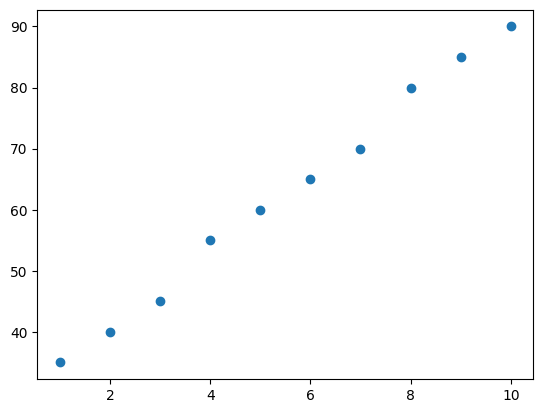

In [5]:
plt.scatter(data['study_hours'],data['marks'])
plt.show()

#### Scatterplot for attendance vs marks

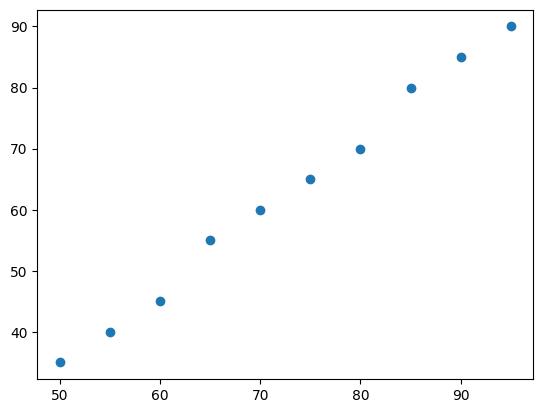

In [6]:
plt.scatter(data['attendance'],data['marks'])
plt.show()

#### LinearRegression Model using study_hours

In [7]:
from sklearn.linear_model import LinearRegression

linear_model_st = LinearRegression()
x_st = data[['study_hours']]
y_marks = data[['marks']]

linear_model_st.fit(x_st,y_marks)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
predict_st = linear_model_st.predict(x_st)
print(predict_st)

[[34.27272727]
 [40.54545455]
 [46.81818182]
 [53.09090909]
 [59.36363636]
 [65.63636364]
 [71.90909091]
 [78.18181818]
 [84.45454545]
 [90.72727273]]


In [9]:
from sklearn.metrics import mean_absolute_error

print("MAE:",mean_absolute_error(y_marks,predict_st))

MAE: 1.1272727272727259


#### LinearRegression Model using attendance

In [10]:
linear_model_atd = LinearRegression()
x_atd = data[['attendance']]
linear_model_atd.fit(x_atd,y_marks)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
predict_atd = linear_model_atd.predict(x_atd)
predict_atd

array([[34.27272727],
       [40.54545455],
       [46.81818182],
       [53.09090909],
       [59.36363636],
       [65.63636364],
       [71.90909091],
       [78.18181818],
       [84.45454545],
       [90.72727273]])

In [12]:
print("MAE:",mean_absolute_error(x_atd,predict_atd))

MAE: 10.000000000000007


In [13]:
data['pass'] = (data['marks']>=50).astype(int)

In [14]:
data

,study_hours,attendance,marks,pass
0,1,50,35,0
1,2,55,40,0
2,3,60,45,0
3,4,65,55,1
4,5,70,60,1
5,6,75,65,1
6,7,80,70,1
7,8,85,80,1
8,9,90,85,1
9,10,95,90,1


#### LogisticRegression Model using study_hours

In [15]:
from sklearn.linear_model import LogisticRegression

X = data[['study_hours']]     
y = data['pass']              

logistic_model_st = LogisticRegression()
logistic_model_st.fit(X, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
predict_st_log = logistic_model_st.predict(X)


In [17]:
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y,predict_st_log))

[[3 0]
 [0 7]]


In [18]:
print(classification_report(y,predict_st_log))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



#### LogisticRegression Model using study_hours

In [19]:
logistic_model_at = LogisticRegression()
x_atd = data[['attendance']]
y = data['pass'] 
logistic_model_at.fit(x_atd,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
predict_logistic_at = logistic_model_at.predict(x_atd)


In [21]:
print(confusion_matrix(y,predict_logistic_at))
print(classification_report(y,predict_logistic_at))

[[3 0]
 [0 7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



- Conclusion :Both models produced identical results because study_hours and attendance are perfectly correlated. This indicates feature redundancy, meaning either feature alone is sufficient for prediction.

### Descision Tree

In [22]:
from sklearn.tree import DecisionTreeClassifier

X = data[['study_hours']]
y = data['pass']
model = DecisionTreeClassifier()
model.fit(X,y)
predict = model.predict(X)
print(predict)


[0 0 0 1 1 1 1 1 1 1]


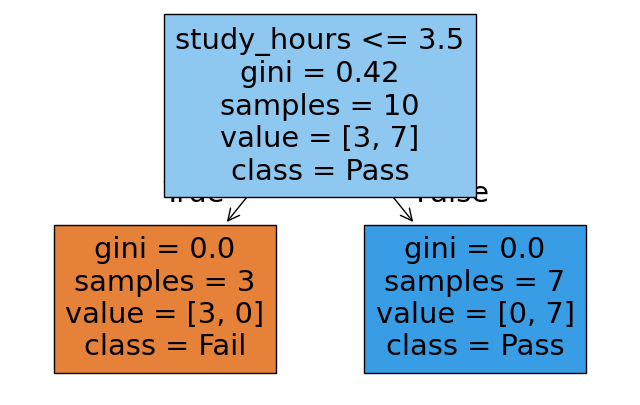

In [23]:
from sklearn.tree import plot_tree
plt.figure(figsize = (8,5))
plot_tree(model,feature_names=['study_hours'],class_names=['Fail','Pass'],filled=True)
plt.show()

- Conclusion:The decision tree learned that students who study more than 3.5 hours are likely to pass, while those who study less are likely to fail

In [24]:
predict1 = model.predict([[3]])
print(predict1)
predict2 = model.predict([[6]])
print(predict2)

[0]
[1]


C:\Users\susha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\susha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## day13_Overfitting

In [25]:
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier(max_depth = 2)
model1.fit(X,y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

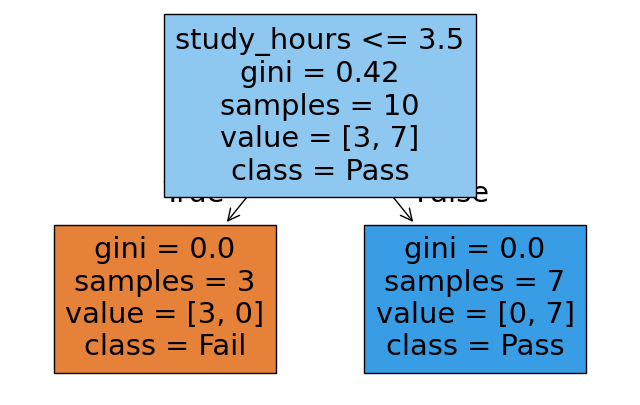

In [26]:
from sklearn.tree import plot_tree
plt.figure(figsize = (8,5))
plot_tree(model1,feature_names=['study_hours'],class_names=['Fail','Pass'],filled=True)
plt.show()

- Dataset is too simple , so limiting depth didn't change anything

#### Modifying Dataset data as data1

In [27]:
data1 = pd.DataFrame({
    'study_hours':[1,2,3,4,5,6,7,8,9,10],
    'attendance':[50,55,60, 65,70,75,80,85,90,95],
    'marks':[35,40,55,45,60,65,50,80,85,70]  # mixed pattern
})

data1["pass"] = (data1["marks"] >= 50).astype(int)

In [28]:
data1

,study_hours,attendance,marks,pass
0,1,50,35,0
1,2,55,40,0
2,3,60,55,1
3,4,65,45,0
4,5,70,60,1
5,6,75,65,1
6,7,80,50,1
7,8,85,80,1
8,9,90,85,1
9,10,95,70,1


In [31]:
X1 = data1[['study_hours']]
y1 = data1['pass']
model1 = DecisionTreeClassifier(max_depth = 2)
model1.fit(X1,y1)
predict1 = model1.predict(X1)
print(predict1)

[0 0 0 0 1 1 1 1 1 1]


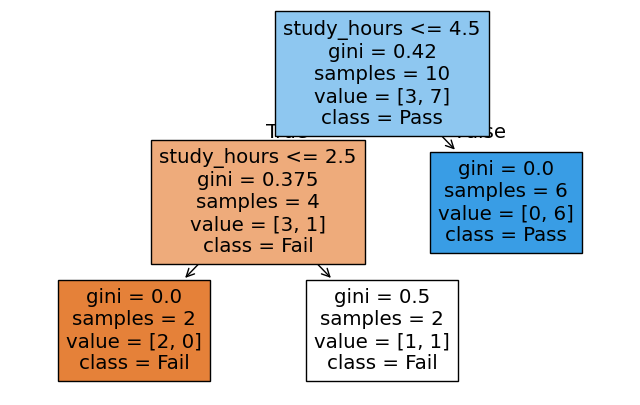

In [32]:
from sklearn.tree import plot_tree
plt.figure(figsize = (8,5))
plot_tree(model1,feature_names=['study_hours'],class_names=['Fail','Pass'],filled=True)
plt.show()

- Conclusion:Students studying more than 4.5 hours are likely to pass. Students studying less than 2.5 hours are likely to fail. Between these ranges, prediction is uncertain.”

- Limiting tree depth prevents the model from memorizing small variations. The model becomes simpler and more general, even though some nodes remain impure